# Step 3a -- given-background model test (fixed background + two clouds)

Uses a *pre-calculated, fixed* background (the skglm quiet-Sun profile
`bdata = new_fit - new_extrafit`) instead of the fitted PCA background of step 3,
and stacks the same two-cloud transfer on top. Checks the per-pixel loss and the
end-to-end gradient path, and runs a short **unregularised** smoke-fit on the
`t = 13` frame.

Because the background here is **fixed** (0 free parameters), the background/cloud
degeneracy of step 3 cannot arise: only the cloud parameters are fit. Sibling of
`step_3_composite_test.ipynb`; see `docs/step_3a_outline.pdf`.

In [1]:
import sys
sys.path.insert(0, '..')          # so cloud_model_torch.py / utils.py (repo root) resolve

import numpy as np
import torch
import matplotlib.pyplot as plt

from composite_model import (init_cloud_params, combine_cloud_params,
                             composite_synth_given, chi2_per_pixel)
from given_background import load_given_background_window, default_bkg_path

%load_ext autoreload
%autoreload 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

device: cuda


In [2]:
# ---- configuration --------------------------------------------------
N     = 10                # trailing snapshots used only to define Iqs (matches step 3)
T     = 13                # fit time step
LAM   = slice(100, 500)   # wavelength crop
YS    = slice(15, -15)    # spatial crop (y)
XS    = slice(15, -15)    # spatial crop (x)

FREEZE_LOGA = True       # log a is a FREE parameter now; set True to freeze it
LOGA_CLAMP  = (-6.0, 0.0) # safe clamp on log a inside the forward (None to disable)

N_ITERS = 1000             # short UNREGULARISED smoke-fit (not a production inversion)
LR      = 2e-2

# the data cube AND the pre-calculated background live in the same directory and
# share the same (t, y, x, lambda) shape.
DATA_NPZ = '/dat/milic/MiHI_filament/mihi_all_data.npz'
BKG_NPZ  = default_bkg_path(DATA_NPZ)   # mihi_rvm_reconstruction_averages_skglm.npz
print("data:", DATA_NPZ)
print("bkg :", BKG_NPZ)

data: /dat/milic/MiHI_filament/mihi_all_data.npz
bkg : /dat/milic/MiHI_filament/mihi_rvm_reconstruction_averages_skglm.npz


In [3]:
# ---- load the fit frame, define Iqs, and load the SAME-window background
f    = np.load(DATA_NPZ, allow_pickle=True)
wav  = np.asarray(f['wav'])
cube = f['data']                                             # (t, y, x, lambda)
blk   = np.copy(cube[-N:, YS, XS, LAM]).astype(np.float32)   # -> defines Iqs
tofit = np.copy(cube[T,   YS, XS, LAM]).astype(np.float32)   # (Ny, Nx, L) -> fit
del f, cube

Iqs       = float(blk[..., -20:].mean())
tofit_n   = tofit / Iqs
Ny, Nx, L = tofit_n.shape
n_pix     = Ny * Nx

# wavelength axis for the cloud model (numpy; cloud_model_torch casts to float32)
xl = [np.copy(wav[LAM]).astype(np.float32),
      np.asarray([np.mean(wav[LAM])], dtype=np.float32)]

# given background bdata = (new_fit - new_extrafit)/Iqs, carved to the SAME crop and
# divided by the SAME Iqs as tofit. Memory-mapped: only frame T is paged in (no 5.8
# GB load). ys/xs = slice(None) -> the whole bordered field (no further crop here).
tofit_pt = torch.from_numpy(tofit_n.reshape(-1, L)).to(device)     # (n_pix, L)
I_in, bshape = load_given_background_window(
    BKG_NPZ, ts=T, YS=YS, XS=XS, lam=LAM,
    ys=slice(None), xs=slice(None), Iqs=Iqs, device=device)

assert I_in.shape == tofit_pt.shape, (I_in.shape, tofit_pt.shape)
assert not I_in.requires_grad
print("I_in:", tuple(I_in.shape), "| n_pix:", n_pix, "| L:", L, "| bg free params: 0")

I_in: (15080, 400) | n_pix: 15080 | L: 400 | bg free params: 0


In [4]:
# ---- parameters: 10 cloud numbers ONLY (0 background degrees of freedom)
cparams   = init_cloud_params(n_pix, device=device, freeze_loga=FREEZE_LOGA)
trainable = [p for p in cparams.values() if p.requires_grad]
free_per_pixel = sum(int(p.requires_grad) for p in cparams.values())
print("cloud params:", len(cparams),
      "| trainable tensors:", len(trainable),
      "| free per pixel:", free_per_pixel)

cloud params: 10 | trainable tensors: 8 | free per pixel: 8


In [5]:
# ---- compose the model (given background) and evaluate the per-pixel loss
syn = composite_synth_given(xl, I_in, combine_cloud_params(cparams), loga_clamp=LOGA_CLAMP)
chi2, loss = chi2_per_pixel(tofit_pt, syn, reduce_mean=True)
print("syn:", tuple(syn.shape), "| chi2 (per-pixel):", tuple(chi2.shape))
print("initial mean per-pixel chi2:", float(loss),
      "| all finite:", bool(torch.isfinite(syn).all()))

syn: (15080, 400) | chi2 (per-pixel): (15080,)
initial mean per-pixel chi2: 8.303349494934082 | all finite: True


/tmp/ipykernel_635288/1825261978.py:5: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("initial mean per-pixel chi2:", float(loss),


In [6]:
# ---- end-to-end gradient check (grads reach the clouds; the background is fixed)
for p in trainable:
    p.grad = None
_, loss0 = chi2_per_pixel(
    tofit_pt,
    composite_synth_given(xl, I_in, combine_cloud_params(cparams), loga_clamp=LOGA_CLAMP),
    reduce_mean=True)
loss0.backward()
print("I_in.requires_grad:", I_in.requires_grad, "(fixed background -> no gradient)")
for k, p in cparams.items():
    g = None if p.grad is None else round(float(p.grad.norm()), 6)
    print(f"  {k:9s} requires_grad={p.requires_grad}  grad_norm={g}")
print("log a is trained here:", (cparams['c1_loga'].grad is not None) and (not FREEZE_LOGA))

I_in.requires_grad: False (fixed background -> no gradient)
  c1_S      requires_grad=True  grad_norm=0.090993
  c1_tau    requires_grad=True  grad_norm=0.001865
  c1_vlos   requires_grad=True  grad_norm=0.001804
  c1_dv     requires_grad=True  grad_norm=0.002704
  c1_loga   requires_grad=False  grad_norm=None
  c2_S      requires_grad=True  grad_norm=0.271561
  c2_tau    requires_grad=True  grad_norm=0.00692
  c2_vlos   requires_grad=True  grad_norm=0.005236
  c2_dv     requires_grad=True  grad_norm=0.006545
  c2_loga   requires_grad=False  grad_norm=None
log a is trained here: False


  0%|          | 0/5000 [00:00<?, ?it/s]

mean per-pixel chi2: 8.3033e+00 -> 1.8182e-01


Text(0.5, 1.0, 'smoke-fit loss (given background)')

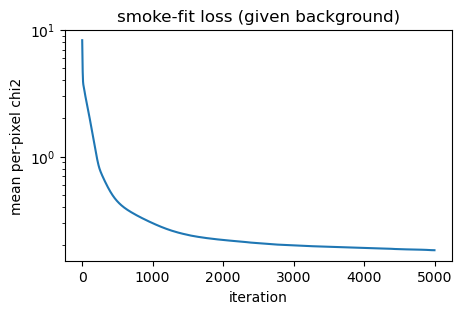

In [7]:
# ---- short UNREGULARISED Adam smoke-fit (differentiability check) ---
from tqdm.auto import trange
opt  = torch.optim.Adam(trainable, lr=LR)
hist = []
for it in trange(N_ITERS*5):
    opt.zero_grad()
    syn = composite_synth_given(xl, I_in, combine_cloud_params(cparams), loga_clamp=LOGA_CLAMP)
    _, loss = chi2_per_pixel(tofit_pt, syn, reduce_mean=True)
    if not torch.isfinite(loss):
        print("non-finite loss at iter", it, "-- stopping"); break
    loss.backward()
    opt.step()
    hist.append(float(loss))
print("mean per-pixel chi2: %.4e -> %.4e" % (hist[0], hist[-1]))
plt.figure(figsize=(5, 3)); plt.semilogy(hist)
plt.xlabel('iteration'); plt.ylabel('mean per-pixel chi2')
plt.title('smoke-fit loss (given background)')

Text(0.5, 1.0, 'log10 mean-sq residual  (field mean 4.55e-04)')

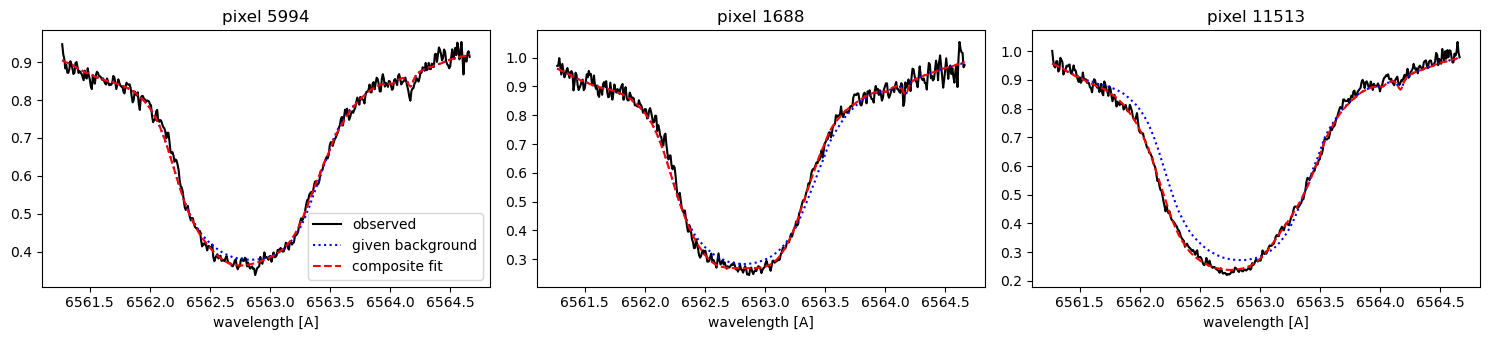

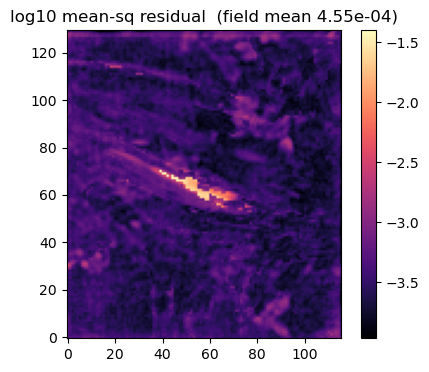

In [10]:
# ---- inspect the fit: data vs composite, plus the FIXED given background
syn    = composite_synth_given(xl, I_in, combine_cloud_params(cparams), loga_clamp=LOGA_CLAMP)
syn_np = syn.detach().cpu().numpy()
bkg_np = I_in.detach().cpu().numpy()          # the fixed given background
wl     = wav[LAM]

np.random.seed(3); idx = np.random.randint(0, n_pix, size=3)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for j, p in enumerate(idx):
    ax[j].plot(wl, tofit_pt[p].cpu().numpy(), 'k',   label='observed')
    ax[j].plot(wl, bkg_np[p],                 'b:',  label='given background')
    ax[j].plot(wl, syn_np[p],                 'r--', label='composite fit')
    ax[j].set_title(f'pixel {p}'); ax[j].set_xlabel('wavelength [A]')
ax[0].legend(); plt.tight_layout()

chi2_map = ((tofit_pt - syn).detach().cpu().numpy() ** 2).sum(-1).reshape(Ny, Nx) / L
plt.figure(figsize=(5, 4))
im = plt.imshow(np.log10(chi2_map).T, origin='lower', cmap='magma'); plt.colorbar(im)
plt.title('log10 mean-sq residual  (field mean %.2e)' % chi2_map.mean())

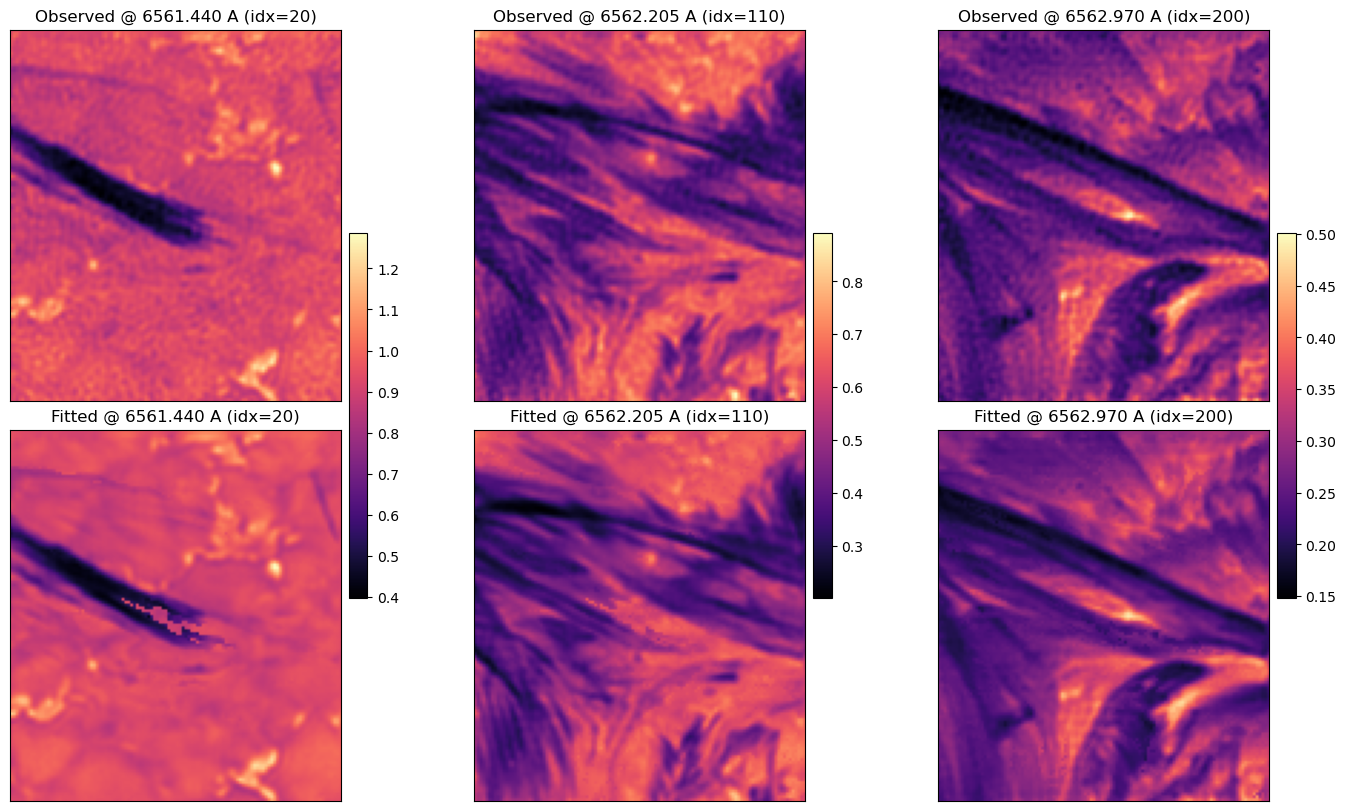

In [11]:
# 6-panel comparison: observed vs fitted images at three wavelengths
import os
os.makedirs('../figs', exist_ok=True)

obs_cube = tofit_pt.detach().cpu().numpy().reshape(Ny, Nx, L)
fit_cube = syn.detach().cpu().numpy().reshape(Ny, Nx, L)
core_idx = L // 2  # index of the line core (approx)

# blue wing, line core, red wing (around the existing core_idx)
wl_idxs = np.clip(np.array([core_idx - 180, core_idx - 90, core_idx]), 0, L - 1)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for j, ii in enumerate(wl_idxs):
    obs_img = obs_cube[:, :, ii]
    fit_img = fit_cube[:, :, ii]
    vmin = min(obs_img.min(), fit_img.min())
    vmax = max(obs_img.max(), fit_img.max())
    im_obs = axes[0, j].imshow(obs_img.T, origin="lower", cmap="magma", vmin=vmin, vmax=vmax, rasterized=True)
    im_fit = axes[1, j].imshow(fit_img.T, origin="lower", cmap="magma", vmin=vmin, vmax=vmax, rasterized=True)
    axes[0, j].set_title(f"Observed @ {wl[ii]:.3f} A (idx={ii})")
    axes[1, j].set_title(f"Fitted @ {wl[ii]:.3f} A (idx={ii})")
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
    fig.colorbar(im_fit, ax=[axes[0, j], axes[1, j]], fraction=0.046, pad=0.02)

plt.savefig("../figs/step_3a_given_fit_images.pdf", dpi=300)

## Notes

- The background here is **fixed** (`bdata = new_fit - new_extrafit`, 0 free
  parameters), so unlike step 3 the background/cloud split is **not degenerate** --
  the background cannot grow emission spikes (or fill its H-alpha core) for the
  clouds to cancel. Only the cloud parameters are fit.
- The given background sits **above** the observed line core; the two clouds supply
  the absorption that brings the composite down onto the data.
- `log a` is free here (clamped to `LOGA_CLAMP` for stability); set
  `FREEZE_LOGA = True` to hold it at (-4, -5). This is still an **unregularised
  per-pixel** smoke-fit -- spatial/temporal regularisation (a PINN, step 4a) is the
  separate outer layer.
- To switch back to the **fitted** PCA background (step 3), feed the same clouds
  through `composite_synth(xl, pca, coeffs, p_cloud)` instead: the two share the same
  physics tail (`_compose`), so the background is just a user-selectable mode.